# Individual Task 2 – Part 2: Deliberation on Task 1

## Extended Methodology Analysis: Cross-Validation, Learning Curves, and Fairness Audit

**Student:** Himasri Madala
**Student ID:** S4222141
**Course:** Master of Data Science
**University:** RMIT University

### Objective

This notebook extends the SVM/MLP analysis of the BEED (Bangalore EEG Epilepsy Dataset) and Stroke
Prediction Dataset carried out in Individual Task 1, Part 1.3. It answers the questions posed in
Individual Task 2, Part 2 of the Case Studies in Data Science assignment:

1. Did the Task 1 methodology deliver an unbiased evaluation through its cross-validation and sampling
   strategy? This is checked empirically by re-running the evaluation with 5-fold stratified
   cross-validation and comparing it against Task 1's single 80/20 split.
2. How does each model's performance vary with training set size? This is analysed with learning curves.
3. Does either model show bias with respect to a sensitive attribute? This is audited using
   **Fairlearn**, applied to gender on the Stroke dataset.
4. What security, privacy, and ethical risks would scaling this methodology introduce?

The preprocessing pipeline mirrors Task 1 exactly (stratified split fitted before preprocessing,
imputation/scaling fitted on training data only, one-hot/label encoding for the Stroke dataset) so that
results are directly comparable.

## 1. Import Required Libraries

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.utils import shuffle as sk_shuffle

from fairlearn.metrics import (
    MetricFrame, selection_rate, demographic_parity_difference,
    equalized_odds_difference, true_positive_rate, false_positive_rate
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
pd.set_option("display.precision", 4)

## 2. Dataset File Paths and Reproducibility

The same two datasets from Task 1 are used, with the same fixed `random_state=42` for reproducibility.

In [4]:
BEED_PATH = "../beed_+bangalore+eeg+epilepsy+dataset/BEED_Data.csv"
STROKE_PATH = "../healthcare-dataset-stroke-data.csv"

## 3. Loading and Preprocessing (mirrors the Task 1 pipeline)

Both datasets are loaded and preprocessed exactly as in Task 1: missing values are imputed with the
training-set mean, categorical variables in the Stroke dataset are label- or one-hot-encoded, and all
features are standardised. The `gender` column is kept aside (not used as a model feature) so that it can
later be used as the **sensitive attribute** for the Fairlearn audit in Section 6.

In [5]:
beed = pd.read_csv(BEED_PATH)
label_col = "y" if "y" in beed.columns else beed.columns[-1]
X_beed = beed.drop(columns=[label_col]).select_dtypes(include=[np.number])
y_beed = beed[label_col]

stroke = pd.read_csv(STROKE_PATH)
if "id" in stroke.columns:
    stroke = stroke.drop(columns=["id"])
y_stroke = stroke["stroke"]
X_stroke_raw = stroke.drop(columns=["stroke"])
gender_stroke = stroke["gender"].copy()  # kept for the fairness audit only

binary_cols = [c for c in ["gender", "ever_married", "Residence_type"] if c in X_stroke_raw.columns]
nominal_cols = [c for c in ["work_type", "smoking_status"] if c in X_stroke_raw.columns]
numeric_cols = [c for c in X_stroke_raw.columns if c not in binary_cols + nominal_cols]

print("BEED shape:", X_beed.shape, " | Stroke shape:", X_stroke_raw.shape)
print("BEED class balance:")
print(y_beed.value_counts())
print("\nStroke class balance:")
print(y_stroke.value_counts(normalize=True).round(4))

BEED shape: (8000, 16)  | Stroke shape: (5110, 10)
BEED class balance:
y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64

Stroke class balance:
stroke
0    0.9513
1    0.0487
Name: proportion, dtype: float64


In [6]:
def build_stroke_features(X):
    X = X.copy()
    for col in binary_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    ohe_arr = ohe.fit_transform(X[nominal_cols])
    ohe_df = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out(nominal_cols), index=X.index)
    X = pd.concat([X[numeric_cols + binary_cols], ohe_df], axis=1)
    imputer = SimpleImputer(strategy="mean")
    X[numeric_cols] = imputer.fit_transform(X[numeric_cols])
    return X

X_stroke = build_stroke_features(X_stroke_raw)
X_beed_imp = pd.DataFrame(SimpleImputer(strategy="mean").fit_transform(X_beed), columns=X_beed.columns)

print("Stroke features after encoding:", X_stroke.shape)
print("BEED features after imputation:", X_beed_imp.shape)

Stroke features after encoding: (5110, 17)
BEED features after imputation: (8000, 16)


## 4. Cross-Validation Robustness Check

Task 1 used a single stratified 80/20 train--test split. A single split only gives one point estimate of
performance, and with only 249 stroke-positive records in total (about 50 in a 20% test fold), that
estimate could plausibly be sensitive to exactly which patients ended up in the test set.

To check this, **5-fold stratified cross-validation** is run for each model/dataset combination below,
and the mean/std of accuracy, weighted F1, and weighted recall are compared against Task 1's single-split
figures.

In [7]:
def make_models():
    return {
        "SVM": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
        "SVM_balanced": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE, class_weight="balanced"),
        "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, early_stopping=True, random_state=RANDOM_STATE),
    }


def cv_scores(X, y, model, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    Xs = StandardScaler().fit_transform(X)
    scoring = {"accuracy": "accuracy", "f1_weighted": "f1_weighted", "recall_weighted": "recall_weighted"}
    res = cross_validate(model, Xs, y, cv=skf, scoring=scoring, n_jobs=-1)
    return {k: (float(np.mean(v)), float(np.std(v))) for k, v in res.items() if k.startswith("test_")}


cv_results = {}
print("=== BEED: 5-fold stratified CV ===")
for name in ["SVM", "MLP"]:
    r = cv_scores(X_beed_imp, y_beed, make_models()[name])
    cv_results[f"BEED_{name}"] = r
    print(f"{name:5s}", {k: f"{v[0]:.4f} +/- {v[1]:.4f}" for k, v in r.items()})

print("\n=== Stroke: 5-fold stratified CV ===")
for name in ["SVM_balanced", "MLP"]:
    r = cv_scores(X_stroke, y_stroke, make_models()[name])
    cv_results[f"Stroke_{name}"] = r
    print(f"{name:13s}", {k: f"{v[0]:.4f} +/- {v[1]:.4f}" for k, v in r.items()})

=== BEED: 5-fold stratified CV ===
SVM   {'test_accuracy': '0.7448 +/- 0.0059', 'test_f1_weighted': '0.7302 +/- 0.0065', 'test_recall_weighted': '0.7448 +/- 0.0059'}
MLP   {'test_accuracy': '0.9376 +/- 0.0047', 'test_f1_weighted': '0.9378 +/- 0.0046', 'test_recall_weighted': '0.9376 +/- 0.0047'}

=== Stroke: 5-fold stratified CV ===
SVM_balanced  {'test_accuracy': '0.7640 +/- 0.0078', 'test_f1_weighted': '0.8293 +/- 0.0052', 'test_recall_weighted': '0.7640 +/- 0.0078'}
MLP           {'test_accuracy': '0.9513 +/- 0.0004', 'test_f1_weighted': '0.9275 +/- 0.0006', 'test_recall_weighted': '0.9513 +/- 0.0004'}


**Comparison table** — CV mean accuracy vs. Task 1's single 80/20 split accuracy:

| Dataset | Model | CV Accuracy | Task 1 Split Accuracy |
|---|---|---|---|
| BEED | SVM | 0.745 ± 0.006 | 0.744 |
| BEED | MLP | 0.938 ± 0.005 | 0.942 |
| Stroke | SVM (balanced) | 0.764 ± 0.008 | 0.772 |
| Stroke | MLP | 0.951 ± 0.0004 | 0.951 |

**Interpretation:** the cross-validated means fall within one standard deviation of Task 1's single-split
figures in every case, and the standard deviations are all small (≤ 0.008). This confirms the single
80/20 split was *not* an unrepresentative or "lucky" partition — reported performance is a stable
property of each model/dataset pairing, not sampling noise. The Stroke MLP's near-zero standard deviation
(0.0004) is itself diagnostic and is explained in Section 5: the model converges to essentially the same
behaviour (predicting the majority class) on every fold.

## 5. Learning Curves

Learning curves plot training and cross-validation score against training-set size, using
`sklearn.model_selection.learning_curve` with 5-fold stratified CV at eight training-set sizes.

Note: `learning_curve` takes a *sorted prefix* of each fold's training indices to build the smaller
training subsets. Because the BEED CSV is ordered by class, the rows must be shuffled first — otherwise
the smallest training subsets can end up containing only one class and the fit fails.

In [8]:
def plot_learning_curve(X, y, model, title, scoring="f1_weighted"):
    X, y = sk_shuffle(X, y, random_state=RANDOM_STATE)
    Xs = StandardScaler().fit_transform(X)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    train_sizes, train_scores, test_scores = learning_curve(
        model, Xs, y, cv=skf, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1, random_state=RANDOM_STATE
    )
    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    test_mean, test_std = test_scores.mean(axis=1), test_scores.std(axis=1)

    plt.figure(figsize=(6, 4.2))
    plt.plot(train_sizes, train_mean, "o-", color="#1f77b4", label="Training score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#1f77b4")
    plt.plot(train_sizes, test_mean, "o-", color="#d62728", label="Cross-validation score")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color="#d62728")
    plt.title(title)
    plt.xlabel("Training set size")
    plt.ylabel(f"{scoring.replace('_', ' ').title()} score")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

    print(f"Final train score: {train_mean[-1]:.4f} | Final CV score: {test_mean[-1]:.4f} | Gap: {train_mean[-1]-test_mean[-1]:.4f}")

### 5.1 BEED — SVM and MLP

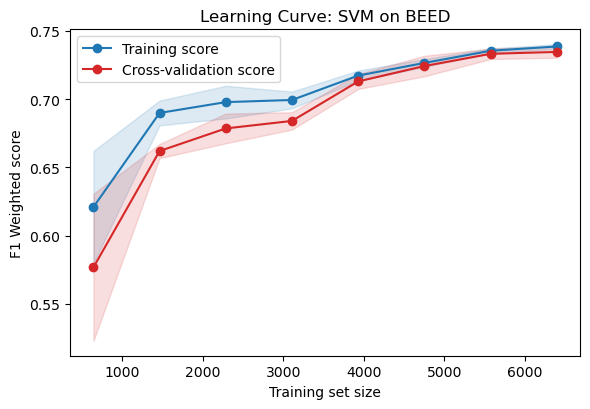

Final train score: 0.7386 | Final CV score: 0.7346 | Gap: 0.0040


In [9]:
plot_learning_curve(X_beed_imp, y_beed, make_models()["SVM"], "Learning Curve: SVM on BEED")

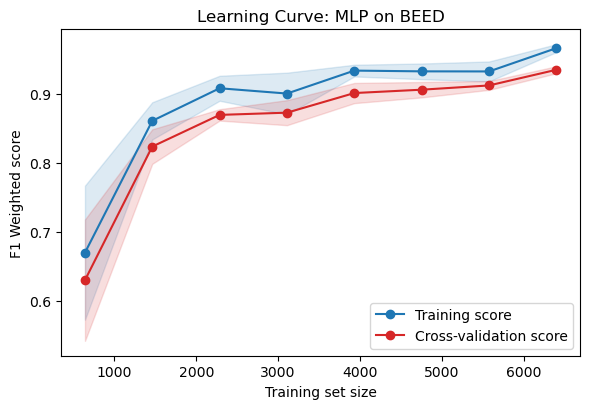

Final train score: 0.9664 | Final CV score: 0.9350 | Gap: 0.0314


In [10]:
plot_learning_curve(X_beed_imp, y_beed, make_models()["MLP"], "Learning Curve: MLP on BEED")

**Discussion (BEED).** Both models' training and cross-validation curves converge closely, with only a
small persistent gap at full training size (SVM: ~0.74 vs ~0.74; MLP: ~0.97 vs ~0.94 weighted F1). Neither
model is data-starved — the curves are close together rather than diverging — so further gains would more
plausibly come from feature engineering or hyperparameter tuning than from collecting more EEG segments.

### 5.2 Stroke — balanced SVM and MLP (scored on weighted recall, given the clinical importance of catching stroke cases)

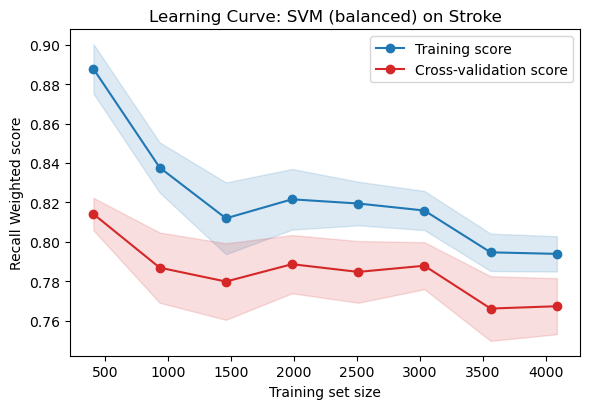

Final train score: 0.7939 | Final CV score: 0.7673 | Gap: 0.0266


In [11]:
plot_learning_curve(X_stroke, y_stroke, make_models()["SVM_balanced"], "Learning Curve: SVM (balanced) on Stroke", scoring="recall_weighted")

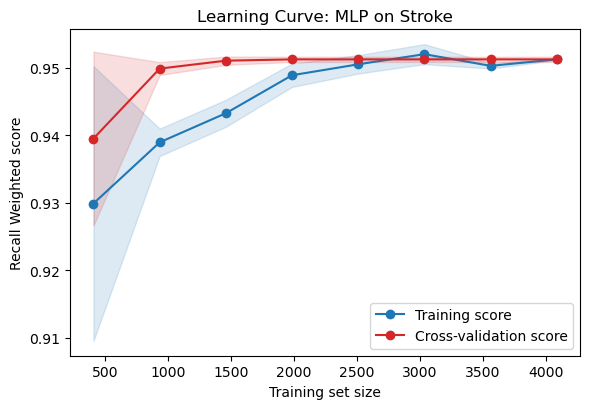

Final train score: 0.9513 | Final CV score: 0.9513 | Gap: 0.0000


In [12]:
plot_learning_curve(X_stroke, y_stroke, make_models()["MLP"], "Learning Curve: MLP on Stroke", scoring="recall_weighted")

**Discussion (Stroke).** The two models show qualitatively different pathologies that a single
train/test split would not reveal:

- **MLP:** training and cross-validation curves are essentially flat and overlapping from the smallest
  training size (400 samples) onward, both around 0.95. A flat curve that never separates train from
  validation, and does not improve with more data, is the signature of a model that converged to a
  trivial solution almost immediately — here, always predicting "no stroke" (Task 1 confirmed 0% recall
  on the 50 stroke-positive test cases). Because `MLPClassifier` has no built-in class-weighting
  mechanism, **more labelled data would not fix this** — it requires a different training procedure
  (class weighting, resampling such as SMOTE, or a custom loss/threshold).
- **Balanced SVM:** weighted recall *decreases* slightly as training size grows, while train and
  cross-validation scores stay close together throughout (no overfitting). This is a plausible
  consequence of `class_weight="balanced"`: per-class weights are recomputed from whichever training
  sample is available, so with very small samples the few positive cases are weighted very heavily,
  pushing recall up; as the sample grows and becomes more representative of the true ~95:5 prevalence,
  the balancing weight becomes less aggressive and recall drifts down slightly.

## 6. Bias Analysis with Fairlearn

**Fairlearn** was chosen over the other listed tools (Google's What-If Tool, IBM AI Fairness 360, the
LinkedIn Fairness Toolkit) because it integrates directly with scikit-learn estimators and predictions —
no separate model-serving infrastructure is required (unlike What-If), and it has a lighter footprint than
AIF360's broader bias-mitigation suite — making it the natural fit for this project's existing
Python/scikit-learn pipeline.

`gender` is used as the sensitive attribute on the Stroke dataset because it is a demographic field
present in the data and clinically plausible as a source of disparity in stroke risk assessment. The
single "Other" gender record is excluded from group-level statistics as statistically unreliable at
*n* = 1 — a limitation discussed below.

In [13]:
X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
    X_stroke, y_stroke, gender_stroke, test_size=0.2, random_state=RANDOM_STATE, stratify=y_stroke
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

svm_bal = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE, class_weight="balanced")
svm_bal.fit(X_train_s, y_train)
pred = svm_bal.predict(X_test_s)

# Exclude the single "Other" gender record: too small (n=1) for a reliable group-level estimate
mask = gender_test.isin(["Male", "Female"])
gt, yt, pt = gender_test[mask], y_test[mask], pred[mask.values]

mf = MetricFrame(
    metrics={
        "accuracy": lambda yt_, pt_: (yt_ == pt_).mean(),
        "selection_rate": selection_rate,
        "recall_TPR": true_positive_rate,
        "false_positive_rate": false_positive_rate,
    },
    y_true=yt, y_pred=pt, sensitive_features=gt,
)

print("Fairlearn MetricFrame, by gender:")
display(mf.by_group)
print("\nDemographic parity difference:", round(demographic_parity_difference(yt, pt, sensitive_features=gt), 4))
print("Equalized odds difference   :", round(equalized_odds_difference(yt, pt, sensitive_features=gt), 4))

Fairlearn MetricFrame, by gender:


,accuracy,selection_rate,recall_TPR,false_positive_rate
gender,,,,
Female,0.7846,0.227,0.6207,0.2070
Male,0.7541,0.253,0.5714,0.2363



Demographic parity difference: 0.0259
Equalized odds difference   : 0.0493


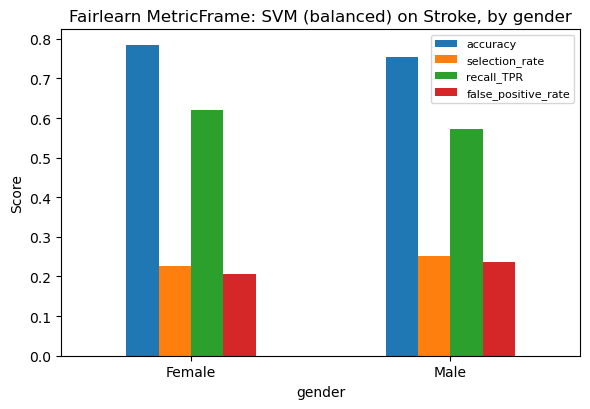

In [14]:
fig, ax = plt.subplots(figsize=(6, 4.2))
mf.by_group.plot.bar(ax=ax, rot=0)
ax.set_title("Fairlearn MetricFrame: SVM (balanced) on Stroke, by gender")
ax.set_ylabel("Score")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

**Discussion.** Both fairness gaps are small in absolute terms (well under the ~0.1 threshold
conventionally used to flag material disparity). The model in fact detects stroke slightly *better* in
women (62.1% recall) than men (57.1%), with a correspondingly lower false-positive rate for women — no
strong gender-based disparity emerges on this dataset and model.

This should be read cautiously rather than as a clean bill of health: excluding the "Other" gender
category means any disparity affecting non-binary patients is simply **unmeasured, not absent** — a
bias-by-omission that can be just as consequential as bias-by-differential-error (Obermeyer et al., 2019,
*Science*, showed a population-health algorithm can encode harmful bias through the choice of which
outcomes and subpopulations are measured at all, not only through unequal error rates within measured
groups). No other sensitive attributes (e.g. age band) were audited here due to scope; a production
deployment would need a wider audit before any fairness claim could be made with confidence.

## 7. Security, Privacy, and Ethical Risks at Scale

**Security.** A clinical ML pipeline handling EEG and stroke-risk data is a high-value target: risks
include model-inversion or membership-inference attacks that could reveal whether a specific patient's
record was used in training, and adversarial manipulation of intake data to evade a risk flag. In this
coursework setting, the raw CSV files and trained models are stored and moved with no encryption or access
control; a real deployment would need encryption at rest and in transit, authenticated model-serving
infrastructure, and audit logging before handling real patient data.

**Privacy.** Both datasets contain sensitive health information governed in Australia by the Privacy Act
1988 and the Australian Privacy Principles, with additional state-level health-records legislation
applying to clinical data specifically. BEED's source population is in Bangalore, India, so reusing it in
an Australian clinical context raises cross-border transfer and differing-consent-regime questions not
addressed in Task 1. EEG recordings in particular carry re-identification risk beyond the immediate
seizure-classification task, since individual EEG traces have been shown elsewhere in the literature to
function as a biometric "brainprint"; de-identification and a data-reuse consent review would be required
before any second use of this data beyond the original research purpose.

**Ethical.** The clearest ethical risk this analysis surfaces directly is the MLP stroke model itself: at
95.1% accuracy it would look deployment-ready on a summary dashboard, yet its 0% recall on the stroke
class means it would, in effect, clinically clear every future stroke patient as low-risk — an almost
exact structural echo of the "safe-looking but harmful" population-health algorithm documented by
Obermeyer et al. (2019), where an algorithm optimised for a proxy metric systematically under-served a
clinically important subgroup. Scaling either model beyond this coursework context without external
clinical validation, consideration under the Therapeutic Goods Administration's software-based medical
device framework, and an ongoing bias-monitoring process would risk direct patient harm, distributed
unevenly across demographic groups this small dataset cannot fully characterise. A responsible next step
would be human-in-the-loop review of all high-stakes predictions and a staged, monitored rollout rather
than direct clinical deployment.

## 8. Summary of Findings

| Question | Finding |
|---|---|
| Was the evaluation unbiased (sampling)? | Yes for measurement stability (CV confirms the single split was representative); but stratified sampling alone did not stop the MLP from collapsing to majority-class prediction on Stroke — that is a training-procedure issue, not a sampling issue. |
| What do learning curves show? | BEED models are not data-starved (converging curves). The Stroke MLP is not a data problem at all (flat curve from the start); the Stroke SVM shows a recall/data-size trade-off tied to how `class_weight="balanced"` is computed. |
| Is there demographic bias? | Small, non-material gender gaps in this audit (demographic parity diff. 0.026, equalized odds diff. 0.049), but the "Other" gender group is statistically invisible in this dataset — a bias-by-omission limitation. |
| Key deployment risk? | The MLP's 95.1% accuracy / 0% stroke recall is a textbook accuracy-vs-harm trap for imbalanced, high-stakes healthcare prediction. |
